# Acrobot Vertical PPO

## 实验目标

本实验使用 `PPO` 训练 Acrobot 的离散动作策略，但目标不是原版环境中的越过指定高度，而是让系统接近完全竖直并短暂保持稳定。这里的重点是把 `PPO` 放到一个更强调姿态控制的摆动任务里，验证它能否在连续状态、离散动作条件下同时学到摆动、减速和对齐。

## 为什么这里选择 PPO

这次继续使用 `PPO`，原因有两点：

- 竖直保持目标比原版 Acrobot 更需要平滑、稳定的策略更新
- 这类任务的瓶颈主要在环境采样，因此固定使用 `CPU + 24` 进程并行环境更直接

因此，这里选择 `PPO + 24 进程并行环境`，优先保证采样吞吐、收敛速度和最终姿态质量。


## 收敛判断方式

这个 notebook 不把“偶尔摆上去一次”当作成功，而是同时检查以下信号：

- 最近回合平均回报是否持续改善
- 最近回合成功率是否逐步上升
- 周期评估中的成功率是否连续稳定
- 评估阶段的平均末端高度是否接近上限
- 两个关节的平均角误差是否持续收紧
- 回放中是否能够摆到接近完全竖直，并保持一段连续帧

只有这些信号同时成立，才说明策略真正学会了上摆、减速和保持。


## 设备与并行说明

- 本实验固定使用 `CPU`
- 使用 `24` 个子进程环境并行采样
- 不使用 `MPS`

原因是这类经典控制任务的主要瓶颈通常在环境交互，而不是网络前向与反向计算。相比切到 `MPS`，`CPU + 24` 进程更能稳定提升有效训练吞吐。


In [1]:
import time
from pathlib import Path

import imageio.v2 as imageio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import SubprocVecEnv, VecMonitor

from vertical_acrobot_env import make_vertical_acrobot_env


In [2]:
ENV_ID = 'VerticalAcrobot'
NUM_ENVS = 24
TOTAL_TIMESTEPS = 3145728
N_STEPS = 256
BATCH_SIZE = 2048
N_EPOCHS = 10
LEARNING_RATE = 3e-4
GAMMA = 0.99
GAE_LAMBDA = 0.95
CLIP_RANGE = 0.2
ENT_COEF = 0.0005
VF_COEF = 0.5
MAX_GRAD_NORM = 0.5
MAX_STEPS = 600
EVAL_EPISODES = 100
PERIODIC_EVAL_EPISODES = 40
EVAL_INTERVAL_STEPS = 262144
EARLY_STOP_SUCCESS_RATE = 0.90
EARLY_STOP_MAX_THETA1_ERROR_DEG = 12.0
EARLY_STOP_MAX_THETA2_ERROR_DEG = 18.0
EARLY_STOP_CONSECUTIVE_EVALS = 3
ROLLOUT_EPISODES = 3
ROLLOUT_FPS = 30
SEED = 42
HOLD_STEPS = 10
DAMPING_1 = 0.01
DAMPING_2 = 0.10

DEVICE = 'cpu'
PARALLEL_MODE = 'subproc_24_cpu'

RESULTS_DIR = Path('results')
RESULTS_DIR.mkdir(exist_ok=True)


## 参数选择说明

这组参数是为长期收敛版本准备的：

- `NUM_ENVS = 24`：扩大采样吞吐
- `TOTAL_TIMESTEPS = 3145728`：给摆起、减速、保持足够长的训练预算
- `N_STEPS = 256`：每轮采样保留更长时序片段
- `BATCH_SIZE = 2048`：提高 PPO 更新统计稳定性
- `ENT_COEF = 0.0005`：减少后期多余探索，帮助策略收住姿态
- `EVAL_INTERVAL_STEPS = 262144`：固定周期做一次评估，避免只在最后看结果
- `EARLY_STOP_CONSECUTIVE_EVALS = 3`：连续三次评估稳定达标后提前停止
- `damping_1 = 0.01` 与 `damping_2 = 0.05`：保持轻微轴承阻尼

如果这组配置仍不稳定，优先继续增加训练步数，而不是改成功条件。


In [3]:
def make_env(rank, render_mode=None):
    def _init():
        env = make_vertical_acrobot_env(
            render_mode=render_mode,
            max_episode_steps=MAX_STEPS,
            hold_steps=HOLD_STEPS,
            damping_1=DAMPING_1,
            damping_2=DAMPING_2,
        )
        env.reset(seed=SEED + rank)
        return Monitor(env)
    return _init

def evaluate_model(model, num_episodes, base_seed):
    records = []
    for episode in range(num_episodes):
        env = make_vertical_acrobot_env(
            max_episode_steps=MAX_STEPS,
            hold_steps=HOLD_STEPS,
            damping_1=DAMPING_1,
            damping_2=DAMPING_2,
        )
        obs, info = env.reset(seed=base_seed + episode)
        total_reward = 0.0
        for step in range(MAX_STEPS):
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(int(action))
            total_reward += reward
            if terminated or truncated:
                records.append({
                    'evaluation_reward': float(total_reward),
                    'evaluation_length': step + 1,
                    'evaluation_success': int(info.get('is_vertical_success', False)),
                    'tip_height': float(info.get('tip_height', np.nan)),
                    'theta1_error_deg': float(np.degrees(info.get('theta1_error', np.nan))),
                    'theta2_error_deg': float(np.degrees(info.get('theta2_error', np.nan))),
                    'success_counter': int(info.get('success_counter', 0)),
                })
                break
        env.close()
    return pd.DataFrame(records)

class EpisodeStatsCallback(BaseCallback):
    def __init__(self):
        super().__init__()
        self.episode_returns = []
        self.episode_lengths = []
        self.episode_successes = []
        self.final_tip_heights = []
        self.final_theta1_errors = []
        self.final_theta2_errors = []
        self.eval_history = []
        self.last_eval_step = 0
        self.eval_index = 0
        self.consecutive_good_evals = 0
        self.early_stop_triggered = False

    def _on_step(self) -> bool:
        infos = self.locals.get('infos', [])
        dones = self.locals.get('dones', [])
        for done, info in zip(dones, infos):
            if done and 'episode' in info:
                self.episode_returns.append(float(info['episode']['r']))
                self.episode_lengths.append(int(info['episode']['l']))
                self.episode_successes.append(int(info.get('is_vertical_success', False)))
                self.final_tip_heights.append(float(info.get('tip_height', np.nan)))
                self.final_theta1_errors.append(float(info.get('theta1_error', np.nan)))
                self.final_theta2_errors.append(float(info.get('theta2_error', np.nan)))

        if self.num_timesteps - self.last_eval_step >= EVAL_INTERVAL_STEPS:
            eval_df = evaluate_model(self.model, PERIODIC_EVAL_EPISODES, SEED + 50000 + self.eval_index * 1000)
            snapshot = {
                'timesteps': int(self.num_timesteps),
                'evaluation_average_return': float(eval_df['evaluation_reward'].mean()),
                'evaluation_average_length': float(eval_df['evaluation_length'].mean()),
                'evaluation_success_rate': float(eval_df['evaluation_success'].mean()),
                'evaluation_average_tip_height': float(eval_df['tip_height'].mean()),
                'evaluation_average_theta1_error_deg': float(eval_df['theta1_error_deg'].mean()),
                'evaluation_average_theta2_error_deg': float(eval_df['theta2_error_deg'].mean()),
            }
            self.eval_history.append(snapshot)
            self.last_eval_step = self.num_timesteps
            self.eval_index += 1

            good_eval = (
                snapshot['evaluation_success_rate'] >= EARLY_STOP_SUCCESS_RATE
                and snapshot['evaluation_average_theta1_error_deg'] <= EARLY_STOP_MAX_THETA1_ERROR_DEG
                and snapshot['evaluation_average_theta2_error_deg'] <= EARLY_STOP_MAX_THETA2_ERROR_DEG
            )
            if good_eval:
                self.consecutive_good_evals += 1
            else:
                self.consecutive_good_evals = 0

            print(
                f"Periodic eval @ {self.num_timesteps}: success={snapshot['evaluation_success_rate']:.3f}, "
                f"theta1={snapshot['evaluation_average_theta1_error_deg']:.2f}, "
                f"theta2={snapshot['evaluation_average_theta2_error_deg']:.2f}, "
                f"good_streak={self.consecutive_good_evals}"
            )

            if self.consecutive_good_evals >= EARLY_STOP_CONSECUTIVE_EVALS:
                self.early_stop_triggered = True
                return False
        return True


In [4]:
train_env = SubprocVecEnv([make_env(i) for i in range(NUM_ENVS)], start_method='fork')
train_env = VecMonitor(train_env)
callback = EpisodeStatsCallback()

model = PPO(
    policy='MlpPolicy',
    env=train_env,
    learning_rate=LEARNING_RATE,
    n_steps=N_STEPS,
    batch_size=BATCH_SIZE,
    n_epochs=N_EPOCHS,
    gamma=GAMMA,
    gae_lambda=GAE_LAMBDA,
    clip_range=CLIP_RANGE,
    ent_coef=ENT_COEF,
    vf_coef=VF_COEF,
    max_grad_norm=MAX_GRAD_NORM,
    policy_kwargs=dict(net_arch=dict(pi=[256, 256], vf=[256, 256])),
    verbose=0,
    seed=SEED,
    device=DEVICE,
)

training_start_time = time.perf_counter()
model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=callback, progress_bar=True)
training_wall_time_seconds = time.perf_counter() - training_start_time
actual_total_timesteps = int(model.num_timesteps)
train_env.close()


/opt/anaconda3/lib/python3.13/site-packages/stable_baselines3/common/vec_env/vec_monitor.py:43: UserWarning: The environment is already wrapped with a `Monitor` wrapperbut you are wrapping it with a `VecMonitor` wrapper, the `Monitor` statistics will beoverwritten by the `VecMonitor` ones.
  warnings.warn(


Output()

Periodic eval @ 262152: success=0.000, theta1=71.84, theta2=96.12, good_streak=0

Periodic eval @ 524304: success=0.000, theta1=85.46, theta2=82.15, good_streak=0

Periodic eval @ 786456: success=0.000, theta1=101.03, theta2=93.09, good_streak=0

In [5]:
episode_return_series = pd.Series(callback.episode_returns, dtype=float)
episode_length_series = pd.Series(callback.episode_lengths, dtype=float)
episode_success_series = pd.Series(callback.episode_successes, dtype=float)
tip_height_series = pd.Series(callback.final_tip_heights, dtype=float)
theta1_error_series = pd.Series(callback.final_theta1_errors, dtype=float)
theta2_error_series = pd.Series(callback.final_theta2_errors, dtype=float)

rolling_return = episode_return_series.rolling(50).mean() if len(episode_return_series) >= 50 else episode_return_series
rolling_length = episode_length_series.rolling(50).mean() if len(episode_length_series) >= 50 else episode_length_series
rolling_success = episode_success_series.rolling(50).mean() if len(episode_success_series) >= 50 else episode_success_series
rolling_tip_height = tip_height_series.rolling(50).mean() if len(tip_height_series) >= 50 else tip_height_series

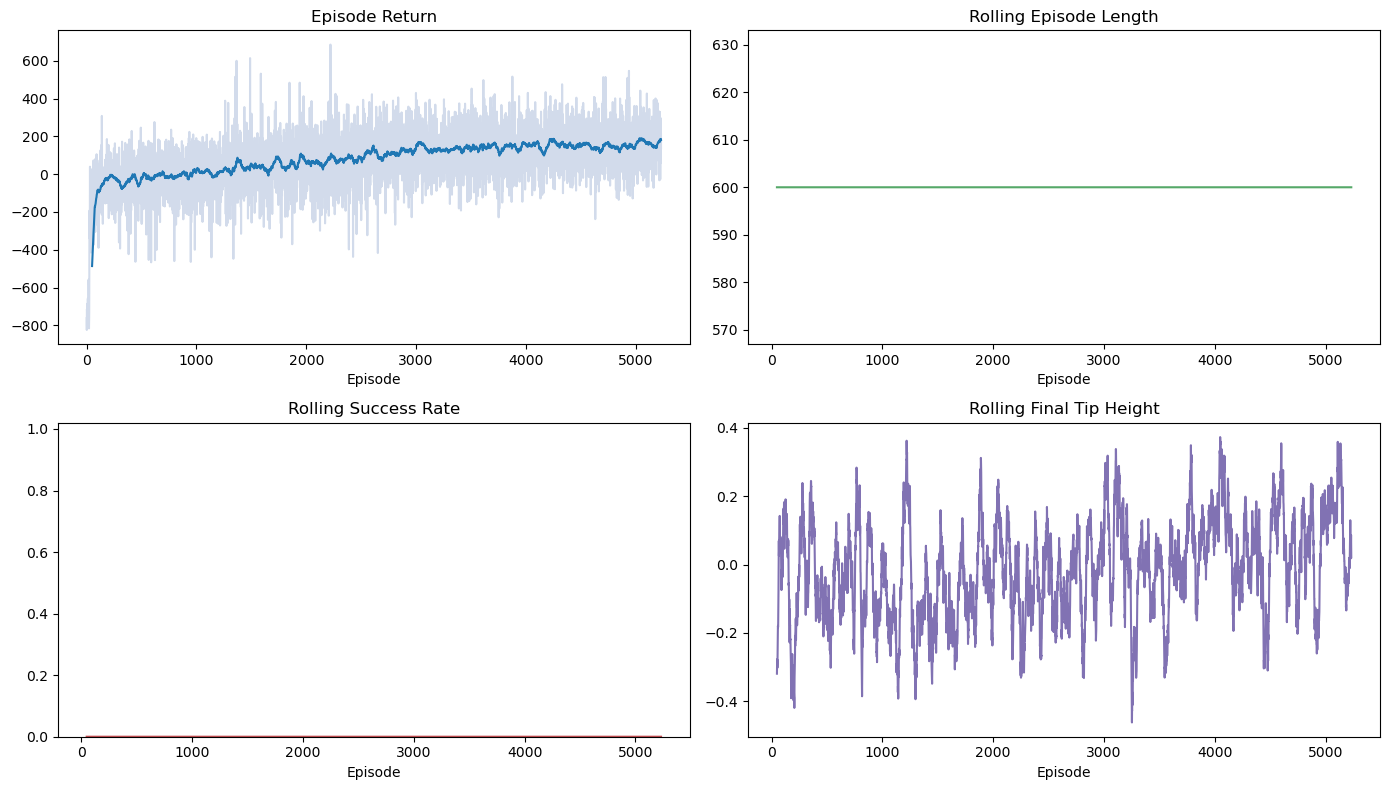

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(episode_return_series, alpha=0.25, color='#4c72b0')
axes[0, 0].plot(rolling_return, color='#1f77b4')
axes[0, 0].set_title('Episode Return')
axes[0, 0].set_xlabel('Episode')

axes[0, 1].plot(rolling_length, color='#55a868')
axes[0, 1].set_title('Rolling Episode Length')
axes[0, 1].set_xlabel('Episode')

axes[1, 0].plot(rolling_success, color='#c44e52')
axes[1, 0].set_title('Rolling Success Rate')
axes[1, 0].set_xlabel('Episode')
axes[1, 0].set_ylim(0, 1.02)

axes[1, 1].plot(rolling_tip_height, color='#8172b3')
axes[1, 1].set_title('Rolling Final Tip Height')
axes[1, 1].set_xlabel('Episode')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'ppo_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
eval_results = evaluate_model(model, EVAL_EPISODES, SEED + 20000)
eval_results.head()


,evaluation_reward,evaluation_length,evaluation_success,tip_height,theta1_error_deg,theta2_error_deg,success_counter
0,144.735342,600,0,-0.034531,104.835956,27.634378,0
1,206.666871,600,0,0.589498,20.920859,131.076836,0
2,291.286300,600,0,0.826855,99.954695,101.300488,0
3,-40.200234,600,0,-0.080030,24.423455,147.691104,0
4,244.905878,600,0,1.947776,0.260085,18.856896,0


In [8]:
recent_return = float(rolling_return.dropna().iloc[-1]) if not rolling_return.dropna().empty else float('nan')
recent_length = float(rolling_length.dropna().iloc[-1]) if not rolling_length.dropna().empty else float('nan')
recent_success = float(rolling_success.dropna().iloc[-1]) if not rolling_success.dropna().empty else float('nan')
periodic_eval_history = pd.DataFrame(callback.eval_history)

metrics = pd.DataFrame({
    'metric': [
        'device',
        'parallel_mode',
        'num_envs',
        'planned_total_timesteps',
        'actual_total_timesteps',
        'hold_steps',
        'damping_1',
        'damping_2',
        'training_wall_time_seconds',
        'periodic_eval_count',
        'early_stop_triggered',
        'recent_episode_return_last_50',
        'recent_episode_length_last_50',
        'recent_success_rate_last_50',
        'evaluation_average_return',
        'evaluation_return_std',
        'evaluation_average_length',
        'evaluation_success_rate',
        'evaluation_average_tip_height',
        'evaluation_average_theta1_error_deg',
        'evaluation_average_theta2_error_deg',
    ],
    'value': [
        DEVICE,
        PARALLEL_MODE,
        NUM_ENVS,
        TOTAL_TIMESTEPS,
        actual_total_timesteps,
        HOLD_STEPS,
        DAMPING_1,
        DAMPING_2,
        training_wall_time_seconds,
        len(callback.eval_history),
        int(callback.early_stop_triggered),
        recent_return,
        recent_length,
        recent_success,
        float(eval_results['evaluation_reward'].mean()),
        float(eval_results['evaluation_reward'].std(ddof=0)),
        float(eval_results['evaluation_length'].mean()),
        float(eval_results['evaluation_success'].mean()),
        float(eval_results['tip_height'].mean()),
        float(eval_results['theta1_error_deg'].mean()),
        float(eval_results['theta2_error_deg'].mean()),
    ],
})
metrics


,metric,value
0,device,cpu
1,parallel_mode,subproc_24_cpu
2,num_envs,24
3,planned_total_timesteps,3145728
4,actual_total_timesteps,3145728
5,hold_steps,10
6,damping_1,0.01
7,damping_2,0.1
8,training_wall_time_seconds,523.156854
9,periodic_eval_count,11


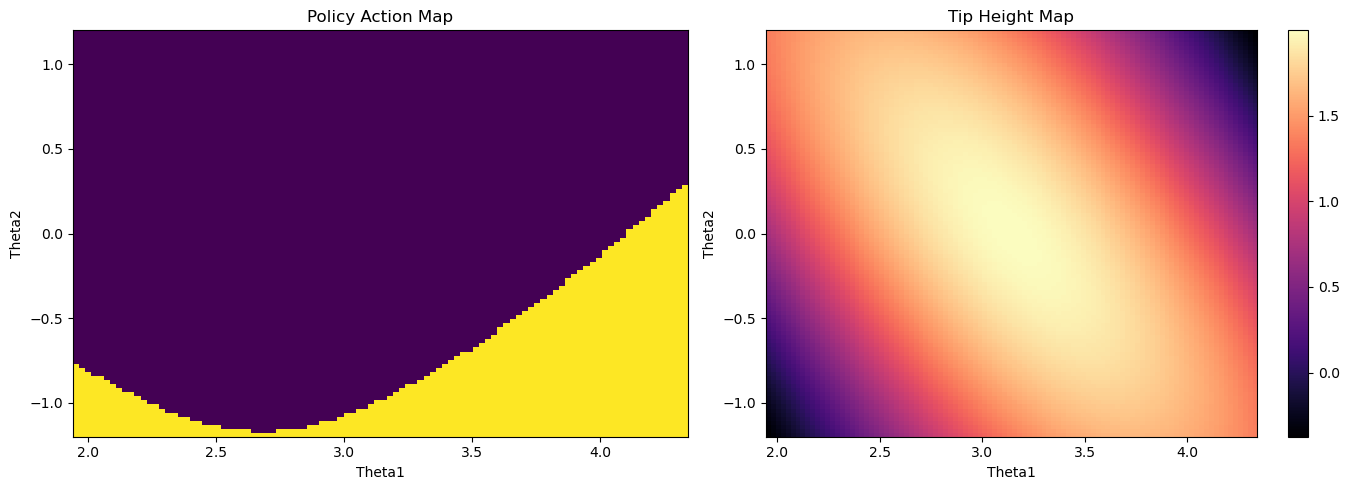

In [9]:
theta1_values = np.linspace(np.pi - 1.2, np.pi + 1.2, 100)
theta2_values = np.linspace(-1.2, 1.2, 100)
action_grid = np.zeros((len(theta2_values), len(theta1_values)))
height_grid = np.zeros_like(action_grid, dtype=float)

for i, theta2 in enumerate(theta2_values):
    for j, theta1 in enumerate(theta1_values):
        obs = np.array([np.cos(theta1), np.sin(theta1), np.cos(theta2), np.sin(theta2), 0.0, 0.0], dtype=np.float32)
        action, _ = model.predict(obs, deterministic=True)
        action_grid[i, j] = int(action)
        height_grid[i, j] = -np.cos(theta1) - np.cos(theta1 + theta2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(action_grid, extent=[theta1_values[0], theta1_values[-1], theta2_values[0], theta2_values[-1]], origin='lower', aspect='auto', cmap='viridis')
axes[0].set_title('Policy Action Map')
axes[0].set_xlabel('Theta1')
axes[0].set_ylabel('Theta2')

height_im = axes[1].imshow(height_grid, extent=[theta1_values[0], theta1_values[-1], theta2_values[0], theta2_values[-1]], origin='lower', aspect='auto', cmap='magma')
axes[1].set_title('Tip Height Map')
axes[1].set_xlabel('Theta1')
axes[1].set_ylabel('Theta2')
fig.colorbar(height_im, ax=axes[1])

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'ppo_policy_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
rollout_summaries = []
for rollout_idx in range(ROLLOUT_EPISODES):
    rollout_env = make_vertical_acrobot_env(render_mode='rgb_array', max_episode_steps=MAX_STEPS, hold_steps=HOLD_STEPS, damping_1=DAMPING_1, damping_2=DAMPING_2)
    obs, info = rollout_env.reset(seed=SEED + 30000 + rollout_idx)
    frames = []
    total_reward = 0.0

    for step in range(MAX_STEPS):
        frame = rollout_env.render()
        if frame is not None:
            frames.append(frame)
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = rollout_env.step(int(action))
        total_reward += reward
        if terminated or truncated:
            final_frame = rollout_env.render()
            if final_frame is not None:
                frames.extend([final_frame] * 30)
            rollout_summaries.append({
                'rollout_index': rollout_idx + 1,
                'seed': SEED + 30000 + rollout_idx,
                'total_reward': float(total_reward),
                'steps': step + 1,
                'success': int(info.get('is_vertical_success', False)),
                'tip_height': float(info.get('tip_height', np.nan)),
                'theta1_error_deg': float(np.degrees(info.get('theta1_error', np.nan))),
                'theta2_error_deg': float(np.degrees(info.get('theta2_error', np.nan))),
                'success_counter': int(info.get('success_counter', 0)),
            })
            break

    if frames:
        imageio.mimsave(RESULTS_DIR / f'ppo_rollout_{rollout_idx + 1}.gif', frames, fps=ROLLOUT_FPS)
    rollout_env.close()

pd.DataFrame(rollout_summaries)

,rollout_index,seed,total_reward,steps,success,tip_height,theta1_error_deg,theta2_error_deg,success_counter
0,1,30042,299.089540,600,0,-0.402493,113.806774,156.259716,0
1,2,30043,65.005075,600,0,-0.000063,179.474236,178.643340,0
2,3,30044,74.690472,600,0,-0.233869,60.605475,75.837573,0


In [11]:
episode_table = pd.DataFrame({
    'episode_return': callback.episode_returns,
    'episode_length': callback.episode_lengths,
    'episode_success': callback.episode_successes,
    'final_tip_height': callback.final_tip_heights,
    'final_theta1_error': callback.final_theta1_errors,
    'final_theta2_error': callback.final_theta2_errors,
})

metrics.to_csv(RESULTS_DIR / 'ppo_metrics.csv', index=False)
episode_table.to_csv(RESULTS_DIR / 'ppo_episode_summary.csv', index=False)
eval_results.to_csv(RESULTS_DIR / 'ppo_eval_results.csv', index=False)
periodic_eval_history.to_csv(RESULTS_DIR / 'ppo_periodic_eval_history.csv', index=False)
pd.DataFrame(rollout_summaries).to_csv(RESULTS_DIR / 'ppo_rollout_summary.csv', index=False)
print(metrics.to_string(index=False))


                             metric          value
                             device            cpu
                      parallel_mode subproc_24_cpu
                           num_envs             24
            planned_total_timesteps        3145728
             actual_total_timesteps        3145728
                         hold_steps             10
                          damping_1           0.01
                          damping_2            0.1
         training_wall_time_seconds     523.156854
                periodic_eval_count             11
               early_stop_triggered              0
      recent_episode_return_last_50     181.813137
      recent_episode_length_last_50          600.0
        recent_success_rate_last_50            0.0
          evaluation_average_return      203.84458
              evaluation_return_std     100.857299
          evaluation_average_length          600.0
            evaluation_success_rate            0.0
      evaluation_average_tip_he

## 结果解读

判断这组结果是否合格，不是只看是否成功过几次，而是要同时看固定评估成功率、末端高度、角误差和回放中的连续保持帧。只有这些指标一起收紧，才说明策略已经学到接近完全竖直的稳定姿态。

## 当前结论

到目前为止，这个实验没有稳定达到目标。这里的问题已经不只是训练时长或超参数，而是任务本身要求智能体在欠驱动系统上同时完成上摆、对齐、减速和保持。仅靠当前这套 `PPO + reward shaping` 方法，虽然可以改变策略行为，但还不足以稳定把系统带到接近完全竖直并连续保持。

如果后续继续推进，合理方向不应只是继续堆训练步数，而应进一步引入更强的结构先验，例如：

- 运动学与动力学分析
- 能量整形或基于能量的摆起策略
- 轨迹规划与目标姿态约束
- 分层控制，先摆起再切换到局部稳定控制
- 将强化学习与经典控制方法结合，而不是单独依赖奖励塑形

因此，这个实验当前更适合作为一个边界案例：它说明了仅靠朴素强化学习设定，在没有额外控制结构支持的情况下，很难稳定完成接近完全竖直并保持的目标。
